# Создание KNN модели

## 1) Первичный анализ данных

In [1]:
 from sklearn.datasets import load_wine
 from sklearn.neighbors import KNeighborsClassifier
 from sklearn import metrics
 import pandas as pd
 import numpy as np
 import seaborn as sns
 from sklearn.preprocessing import StandardScaler
 from sklearn.model_selection import train_test_split
 from sklearn.metrics import accuracy_score
 from sklearn.model_selection import GridSearchCV
 import matplotlib.pyplot as plt
 import seaborn as sns
 from sklearn.metrics import classification_report, confusion_matrix
 
 import matplotlib.pyplot as plt

In [2]:
wine=load_wine()
type(wine)

sklearn.utils._bunch.Bunch

In [3]:
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [4]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [5]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:
df=pd.DataFrame(wine.data, columns=wine.feature_names)

In [7]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [8]:
df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

In [9]:
print(df.shape)

(178, 13)


In [10]:
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Поиск возможных проблем

In [11]:
#пропуски
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

Вывод : пропусков нет, дубликатов нет, мало выбросов

<Axes: xlabel='target', ylabel='proline'>

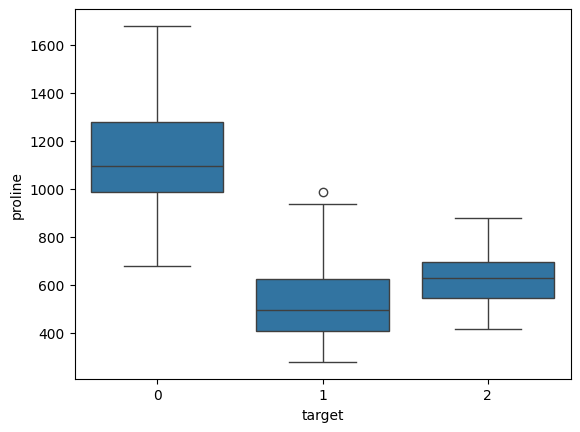

In [13]:
sns.boxplot(y='proline', x='target',data=df )

In [14]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


 Проблема с масштабом

<Axes: xlabel='alcohol', ylabel='proline'>

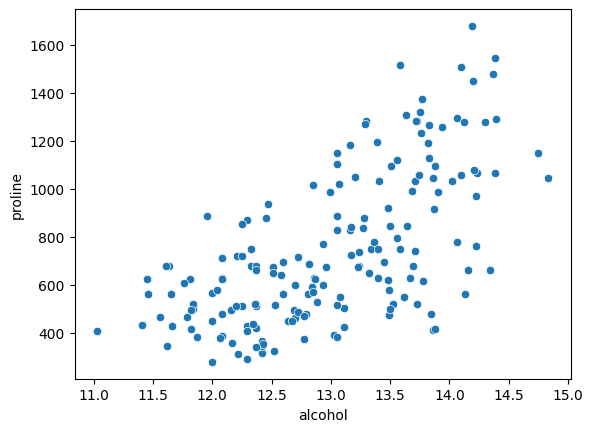

In [15]:
sns.scatterplot(data=df, x='alcohol', y='proline')

In [16]:
# строим распределение классов - сколько сорт вин относится к каждлму классу
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [17]:
# Ращделяем
X = df.drop('target', axis=1)
y = df['target'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,  
    test_size=0.3,
    random_state=42
)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # учимся только на train
X_test_scaled = scaler.transform(X_test)        # применяем к test

# 3. Превращаем обратно в DataFrame (для удобства)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 4. Проверяем результат
print("Train после масштабирования:")
print(X_train_scaled_df.describe())

Train после масштабирования:
            alcohol    malic_acid           ash  alcalinity_of_ash  \
count  1.240000e+02  1.240000e+02  1.240000e+02       1.240000e+02   
mean  -1.706520e-15  1.139322e-16  1.330925e-15      -2.820325e-17   
std    1.004057e+00  1.004057e+00  1.004057e+00       1.004057e+00   
min   -2.306809e+00 -1.378117e+00 -3.716829e+00      -2.564800e+00   
25%   -8.033849e-01 -6.949718e-01 -5.505861e-01      -6.195865e-01   
50%   -2.184314e-02 -4.581481e-01 -2.441756e-02       0.000000e+00   
75%    8.730520e-01  6.986447e-01  5.755992e-01       5.763595e-01   
max    2.227327e+00  3.094208e+00  3.187980e+00       3.025888e+00   

          magnesium  total_phenols    flavanoids  nonflavanoid_phenols  \
count  1.240000e+02   1.240000e+02  1.240000e+02          1.240000e+02   
mean   2.334602e-16   5.090014e-16  1.141560e-17          4.268539e-16   
std    1.004057e+00   1.004057e+00  1.004057e+00          1.004057e+00   
min   -2.017542e+00  -1.986279e+00 -1.656120

 Вывод:
 1) Масштабирование важно для KNN. Так как метод основывается на вычислении расствояний между объектами. Масштабирование выравнивает все признаки, т е каждый вносит 
 равный вклад в поиск соседей
 2) Нельзя подбирать параметры на тестовой выборке. Если вы подстроите параметры под тест, модель обучится на шумах именно этой выборки. Мы получим нечестную оценку, которая не отражает реальную способность модели работать с новыми данными

In [19]:
# Разные значения n_neighbors
neighbors_values = [1, 3, 5, 7, 9, 11, 13, 15]
weights_options = ['uniform', 'distance']
metrics = ['euclidean', 'manhattan', 'minkowski']

results = []

for n in neighbors_values:
    for weight in weights_options:
        for metric in metrics:
            knn = KNeighborsClassifier(n_neighbors=n, weights=weight, metric=metric)
            knn.fit(X_train_scaled, y_train)
            y_pred = knn.predict(X_test_scaled)
            accuracy = accuracy_score(y_test, y_pred)
            results.append({
                'n_neighbors': n,
                'weights': weight,
                'metric': metric,
                'accuracy': accuracy
            })

# Конвертируем результаты в DataFrame
results_df = pd.DataFrame(results)
print("\nЛучшие 5 комбинаций параметров:")
print(results_df.sort_values('accuracy', ascending=False).head(10))



Лучшие 5 комбинаций параметров:
    n_neighbors   weights     metric  accuracy
24            9   uniform  euclidean  0.981481
26            9   uniform  minkowski  0.981481
27            9  distance  euclidean  0.981481
29            9  distance  minkowski  0.981481
44           15   uniform  minkowski  0.981481
45           15  distance  euclidean  0.981481
47           15  distance  minkowski  0.981481
42           15   uniform  euclidean  0.981481
20            7   uniform  minkowski  0.981481
21            7  distance  euclidean  0.981481


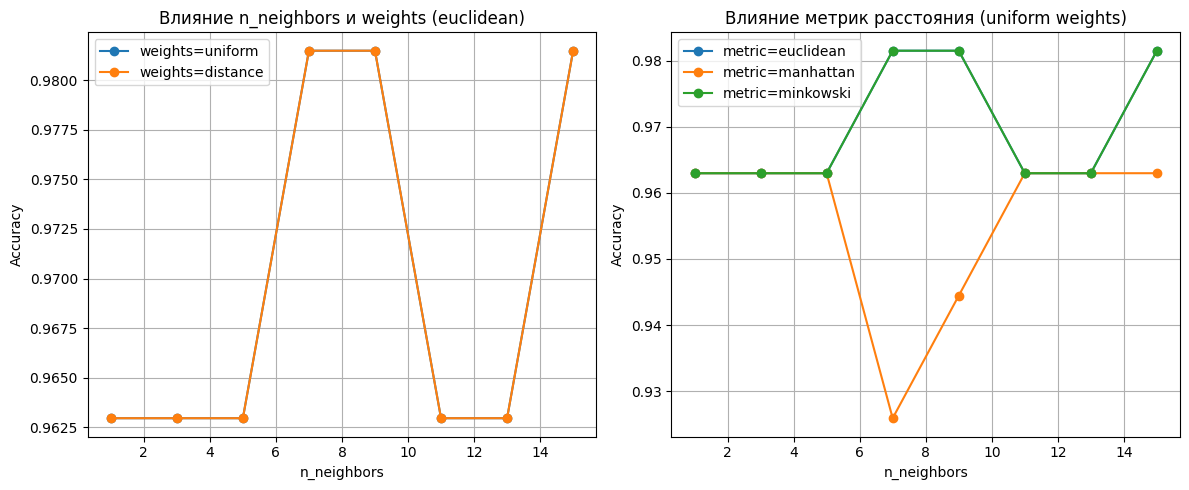

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for weight in weights_options:
    for metric in metrics[:1]:  # только для euclidean
        subset = results_df[(results_df['weights'] == weight) & (results_df['metric'] == 'euclidean')]
        plt.plot(subset['n_neighbors'], subset['accuracy'], marker='o', label=f'weights={weight}')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('Влияние n_neighbors и weights (euclidean)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for metric in metrics:
    subset = results_df[(results_df['weights'] == 'uniform') & (results_df['metric'] == metric)]
    plt.plot(subset['n_neighbors'], subset['accuracy'], marker='o', label=f'metric={metric}')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('Влияние метрик расстояния (uniform weights)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # для Minkowski: p=1 (Manhattan), p=2 (Euclidean)
}


In [22]:
knn_scaled = KNeighborsClassifier()
grid_search_scaler = GridSearchCV(
    knn_scaled, param_grid, 
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_scaler.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search_scaler.best_params_}")
print(f"Лучшая точность на CV: {grid_search_scaler.best_score_:.4f}")
print(f"Точность на тесте: {grid_search_scaler.score(X_test_scaled, y_test):.4f}")

Fitting 5 folds for each of 84 candidates, totalling 420 fits
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Лучшая точность на CV: 0.9680
Точность на тесте: 0.9815



Отчет классификации для лучшей модели:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



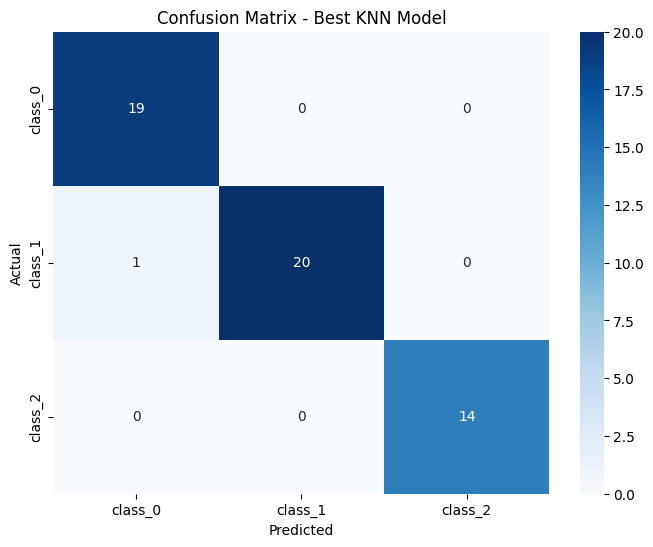

In [23]:
best_knn = grid_search_scaler.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)

print("\nОтчет классификации для лучшей модели:")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine.target_names, 
            yticklabels=wine.target_names)
plt.title('Confusion Matrix - Best KNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()